In [1]:
import pandas as pd
df = pd.read_csv('USA_cars_datasets.csv')
df.head(10)

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left
5,5,5700,dodge,mpv,2018,clean vehicle,45561.0,white,2c4rdgeg9jr237989,167655771,texas,usa,2 days left
6,6,7300,chevrolet,pk,2010,clean vehicle,149050.0,black,1gcsksea1az121133,167753872,georgia,usa,22 hours left
7,7,13350,gmc,door,2017,clean vehicle,23525.0,gray,1gks2gkc3hr326762,167692494,california,usa,20 hours left
8,8,14600,chevrolet,malibu,2018,clean vehicle,9371.0,silver,1g1zd5st5jf191860,167763267,florida,usa,22 hours left
9,9,5250,ford,mpv,2017,clean vehicle,63418.0,black,2fmpk3j92hbc12542,167656121,texas,usa,2 days left


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2499 non-null   int64  
 1   price         2499 non-null   int64  
 2   brand         2499 non-null   object 
 3   model         2499 non-null   object 
 4   year          2499 non-null   int64  
 5   title_status  2499 non-null   object 
 6   mileage       2499 non-null   float64
 7   color         2499 non-null   object 
 8   vin           2499 non-null   object 
 9   lot           2499 non-null   int64  
 10  state         2499 non-null   object 
 11  country       2499 non-null   object 
 12  condition     2499 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 253.9+ KB


,Unnamed: 0,price,year,mileage,lot
count,2499.000000,2499.000000,2499.000000,2.499000e+03,2.499000e+03
mean,1249.000000,18767.671469,2016.714286,5.229869e+04,1.676914e+08
std,721.543484,12116.094936,3.442656,5.970552e+04,2.038772e+05
min,0.000000,0.000000,1973.000000,0.000000e+00,1.593488e+08
25%,624.500000,10200.000000,2016.000000,2.146650e+04,1.676253e+08
50%,1249.000000,16900.000000,2018.000000,3.536500e+04,1.677451e+08
75%,1873.500000,25555.500000,2019.000000,6.347250e+04,1.677798e+08
max,2498.000000,84900.000000,2020.000000,1.017936e+06,1.678055e+08


# Visalizations - Plotting

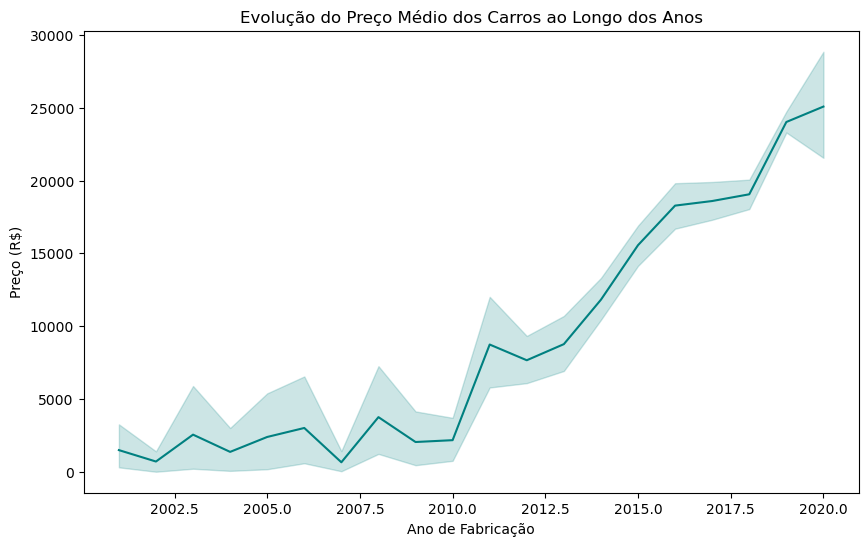

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df1 = df[df['year']>2000]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df1, x='year', y='price', color='teal', errorbar='ci')
plt.title('Evolução do Preço Médio dos Carros ao Longo dos Anos')
plt.xlabel('Ano de Fabricação')
plt.ylabel('Preço (R$)')
plt.show()

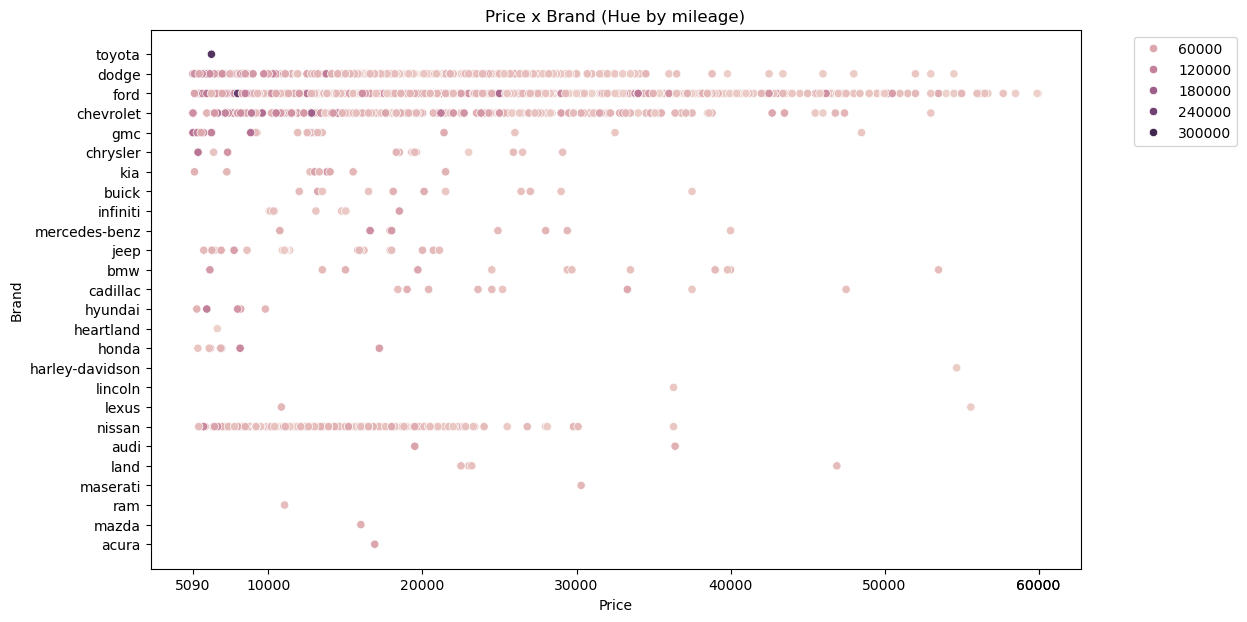

In [39]:
df2 = df[ (5000 < df['price']) & (df['price']<60000)]
x_min = df2['price'].min()

plt.figure(figsize=(12, 7))
ax = sns.scatterplot(data=df2, x='price', y='brand', hue='mileage', alpha=1)  # <-- captura ax

ticks = ax.get_xticks()
ax.set_xticks([x_min, *ticks[1:-1], 60000])

plt.title('Price x Brand (Hue by mileage)')
plt.xlabel('Price')
plt.ylabel('Brand')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

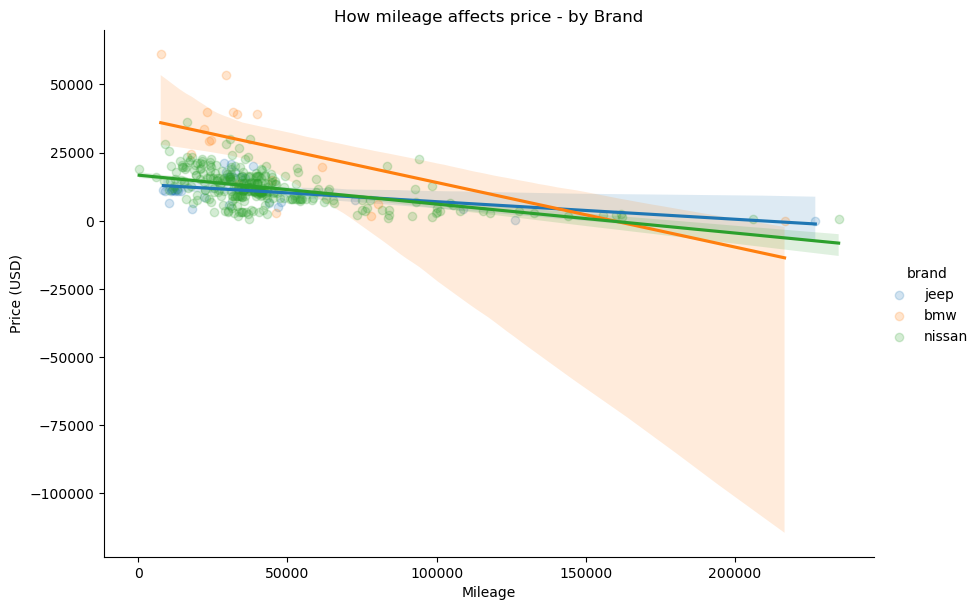

In [63]:
df3 = df[df['brand'].isin(['bmw','nissan', 'jeep'])]
df3 = df3[ (200 < df3['mileage']) & (df3['mileage']<400000)]
sns.lmplot(data=df3, x='mileage', y='price', hue='brand', height=6, aspect=1.5, scatter_kws={'alpha':0.2})
plt.title('How mileage affects price - by Brand')
plt.xlabel('Mileage')
plt.ylabel('Price (USD)')
plt.show()

C:\Users\doger\AppData\Local\Temp\ipykernel_24012\1035325722.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


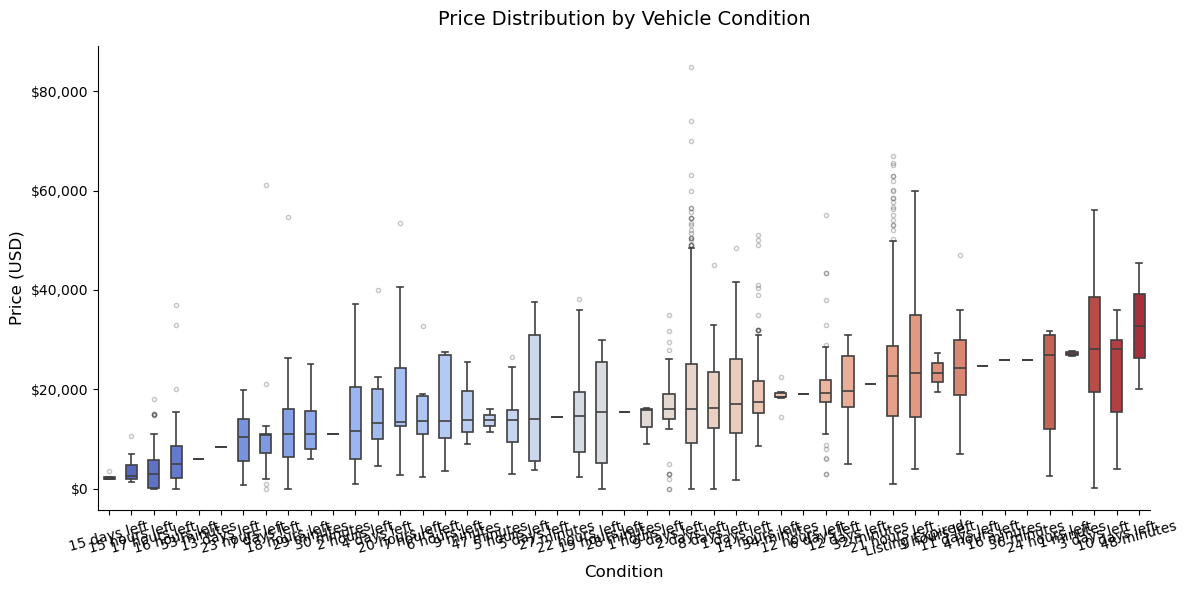

In [67]:
plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df,
    x='condition',
    y='price',
    order=df.groupby('condition')['price'].median().sort_values().index,
    palette='coolwarm',
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.3)  # smaller outliers
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))  # format Y axis as currency

plt.title('Price Distribution by Vehicle Condition', fontsize=14, pad=15)
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.xticks(rotation=15)

sns.despine()  # removes top and right borders
plt.tight_layout()
plt.show()
